# Predictive Maintenance — Leakage-Free Preprocessing Pipeline
### AI4I 2020 Predictive Maintenance Dataset · Multi-Class Target (7 classes)

**Author:** Mahmoud
**Goal:** Build a clean, professional, leakage-free preprocessing pipeline for a multi-class
predictive maintenance problem. No modeling is performed in this notebook — the output is
model-ready train/test data.

**A note on the target column.** The raw AI4I 2020 dataset (UCI / Kaggle, Matzka 2020) does
**not** ship with a ready-made `Reason of Failure` column. It ships with a binary
`Machine failure` label plus five binary failure-mode flags: `TWF`, `HDF`, `PWF`, `OSF`, `RNF`.
To get the requested 7-class target, this notebook **derives** `Reason of Failure` from those
five flags:

| Class | Meaning |
|---|---|
| `No Failure` | all five flags are 0 |
| `TWF` / `HDF` / `PWF` / `OSF` / `RNF` | exactly one flag is 1 (that failure mode) |
| `Multiple Failures` | more than one flag is 1 at the same time (a genuine, rare edge case in this dataset) |

That gives exactly **7 categories**, built from the raw data with full transparency about how
each label was produced — this is done explicitly in Section 2 below, right after loading the
raw file, so nothing about the target is a black box.

**Why start from the raw file at all?** A previous version of this pipeline was built on top of
a pre-scaled / pre-balanced derivative of this dataset. That is a leakage risk on two fronts:
scaling parameters computed on the full dataset bleed test-set information into training, and a
pre-balanced file means the class balancing (e.g. SMOTE) was already applied before any
train/test split existed — the exact thing we're avoiding here. This notebook starts from
`ai4i2020.csv`, the untouched raw release, and does every transformation ourselves, in the
correct order.

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (8, 5)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load Raw Data & Build the Target

Loading the untouched raw file — 10,000 rows, 14 columns, no scaling, no balancing applied.

In [2]:
df_raw = pd.read_csv("ai4i2020.csv")
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### 2.1 Deriving `Reason of Failure`

Rule: if no flag is set → `No Failure`. If exactly one flag is set → that flag's name. If more
than one flag is set at once → `Multiple Failures`.

In [3]:
FAILURE_FLAGS = ["TWF", "HDF", "PWF", "OSF", "RNF"]

def derive_reason_of_failure(row):
    active = [f for f in FAILURE_FLAGS if row[f] == 1]
    if len(active) == 0:
        return "No Failure"
    if len(active) > 1:
        return "Multiple Failures"
    return active[0]

df = df_raw.copy()
df["Reason of Failure"] = df.apply(derive_reason_of_failure, axis=1)

print("Number of classes:", df["Reason of Failure"].nunique())
df["Reason of Failure"].value_counts()

Number of classes: 7


Reason of Failure
No Failure           9652
HDF                   106
PWF                    80
OSF                    78
TWF                    42
Multiple Failures      24
RNF                    18
Name: count, dtype: int64

## 3. Dataset Overview

In [4]:
df.shape

(10000, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
 14  Reason of Failure      

In [6]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### 3.1 Missing Values & Duplicates

In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal duplicate rows:", df.duplicated().sum())

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
Reason of Failure          0
dtype: int64

Total duplicate rows: 0


**Observation:** the AI4I 2020 dataset is synthetically generated and ships with zero
missing values and zero duplicate rows — confirmed above. This is typical of this dataset and
means we can move straight to analysis without an imputation step.

## 4. Target Analysis

In [8]:
counts = df["Reason of Failure"].value_counts()
percentages = df["Reason of Failure"].value_counts(normalize=True) * 100

summary = pd.DataFrame({"count": counts, "percentage": percentages.round(2)})
summary

,count,percentage
Reason of Failure,,
No Failure,9652,96.52
HDF,106,1.06
PWF,80,0.80
OSF,78,0.78
TWF,42,0.42
Multiple Failures,24,0.24
RNF,18,0.18


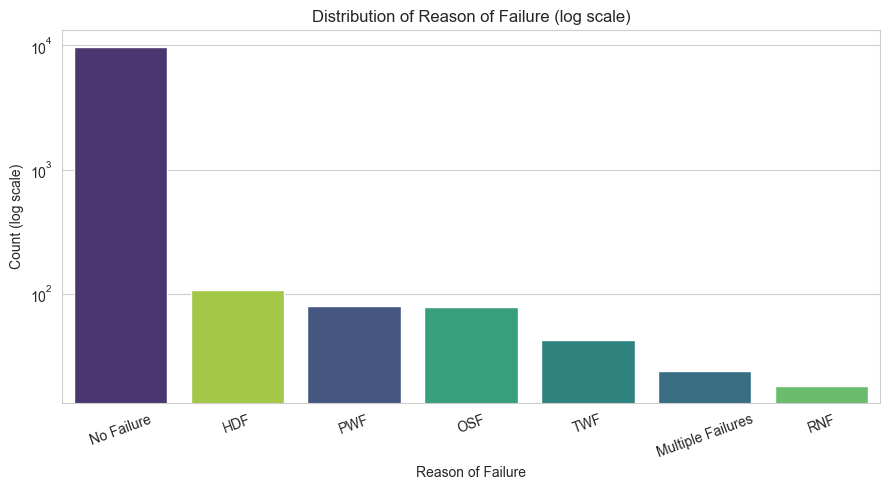

In [9]:
plt.figure(figsize=(9, 5))
order = df["Reason of Failure"].value_counts().index
ax = sns.countplot(x="Reason of Failure", data=df, order=order, hue="Reason of Failure",
                    palette="viridis", legend=False)
ax.set_yscale("log")
plt.title("Distribution of Reason of Failure (log scale)")
plt.ylabel("Count (log scale)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**On the imbalance problem.** `No Failure` accounts for roughly 96–97% of all rows, while
the six failure classes share the remaining 3–4%. The rarest classes (`RNF`, `Multiple Failures`,
`TWF`) have under 50 samples each. This is a severe multi-class imbalance, for three reasons that
matter for what comes later:

1. A model that always predicts `No Failure` would already score ~96% accuracy while being
   completely useless — accuracy is the wrong metric here (precision/recall/F1 per class, or
   macro/weighted F1, matter far more).
2. The minority classes carry the information we actually care about in a predictive-maintenance
   system — missing a real failure is far costlier than a false alarm.
3. Left untouched, most classifiers will be biased toward the majority class simply because it
   dominates the loss function. This is exactly why SMOTE is applied later — but only after the
   train/test split, and only to the training set, so the test set still reflects the real-world
   imbalance the model will face in production.

## 5. Univariate Analysis

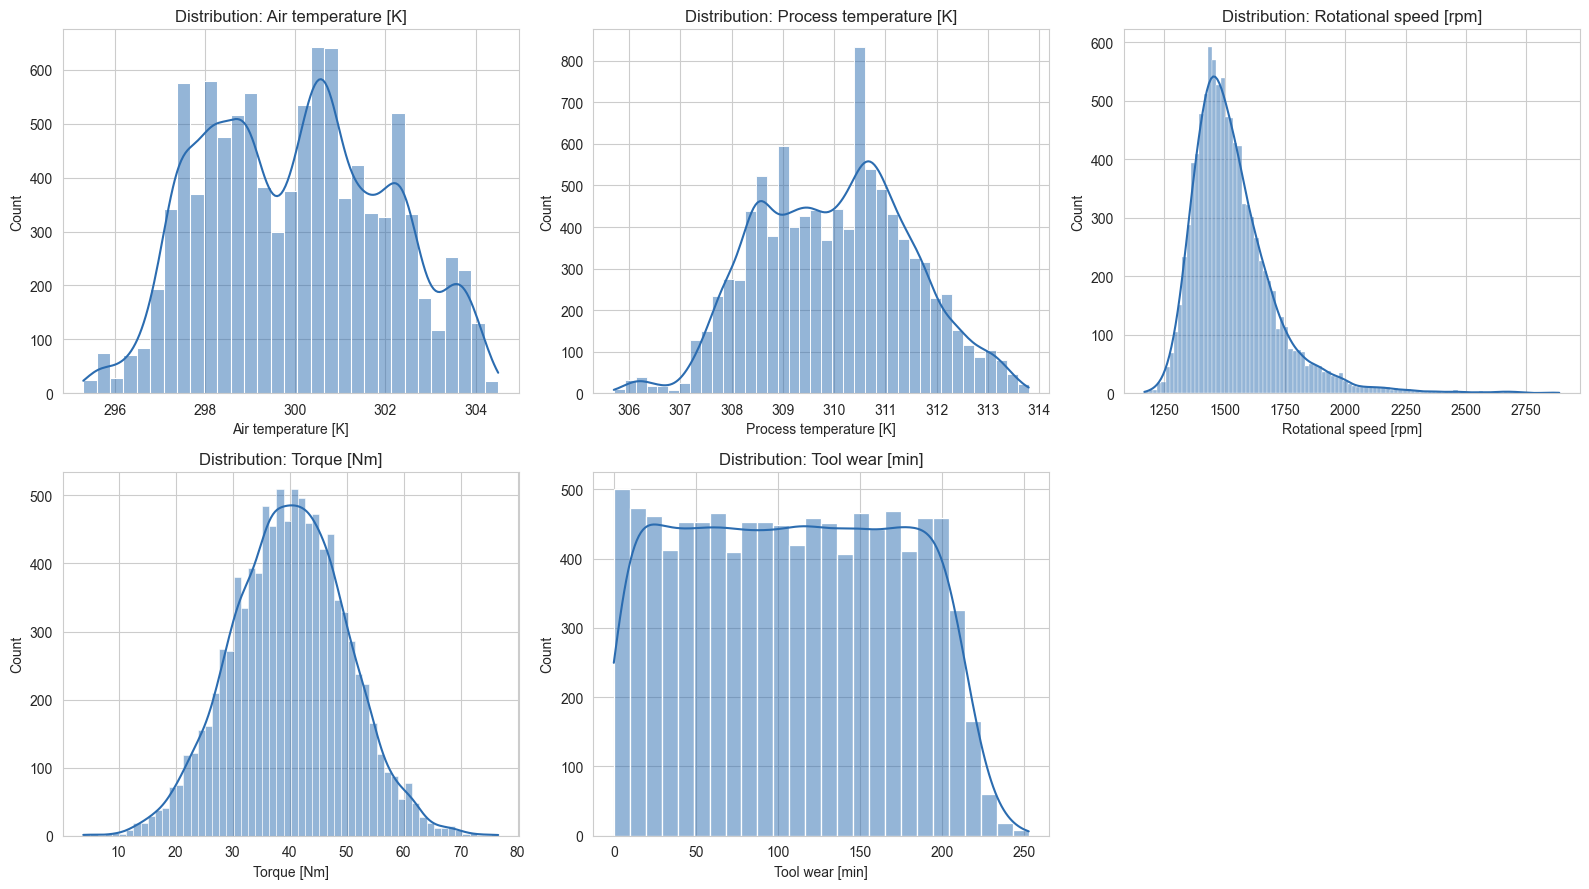

In [10]:
numeric_cols = ["Air temperature [K]", "Process temperature [K]",
                "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color="#2b6cb0")
    axes[i].set_title(f"Distribution: {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()

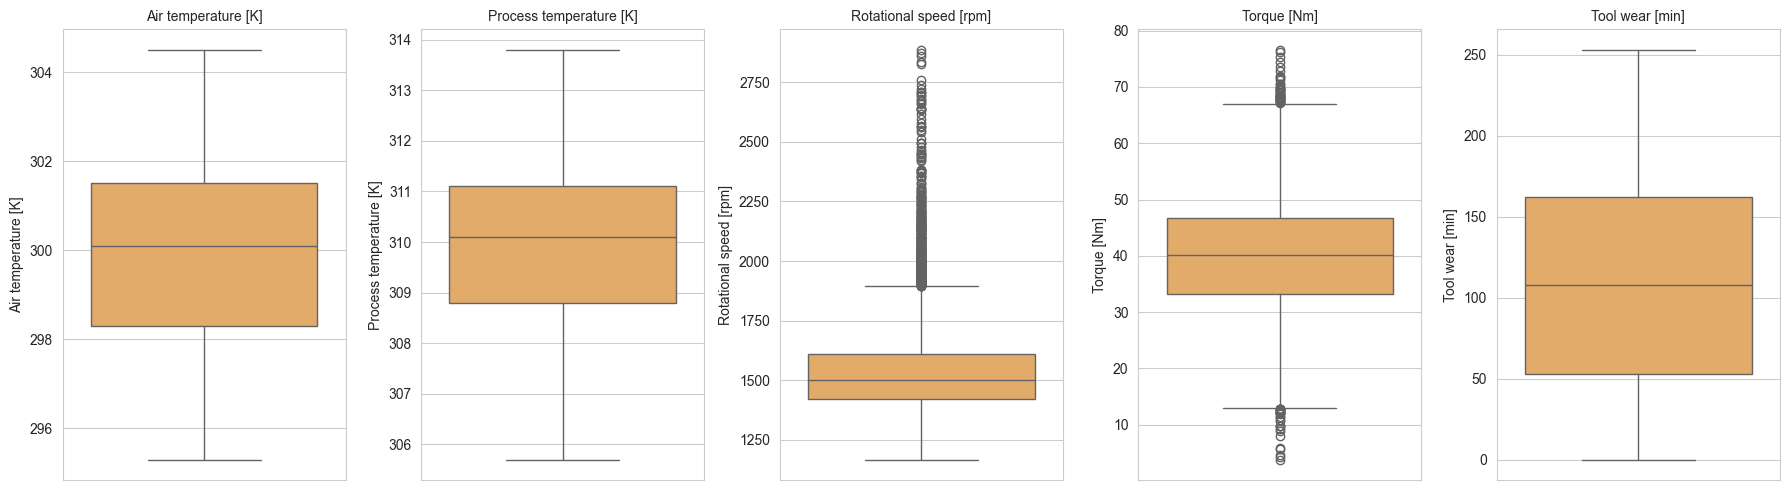

In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(numeric_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="#f6ad55")
    axes[i].set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

**Observations:**

- `Air temperature [K]` and `Process temperature [K]` are both roughly bell-shaped and tightly
  banded (as expected — process temperature is generated as air temperature + a normalized
  offset in the original data-generation process), with almost no extreme outliers.
- `Rotational speed [rpm]` is right-skewed with a long tail of high-speed readings — these tail
  values are exactly where `Power Failure` and `Overstrain Failure` tend to occur mechanically.
- `Torque [Nm]` is close to normally distributed but shows boxplot outliers at both ends; the low
  end is mechanically linked to `Power Failure` (insufficient torque) and the high end to
  `Overstrain Failure`.
- `Tool wear [min]` is close to uniform between 0 and 253 minutes (by design of the simulation)
  and is the direct driver of `Tool Wear Failure` once wear exceeds a threshold.
- None of these boxplot "outliers" look like data-entry errors — they sit inside physically
  plausible ranges and, as Section 6 shows, several are directly tied to specific failure modes.
  We keep them rather than removing them, since deleting them would delete real failure signal.

## 6. Bivariate Analysis

### 6.1 Correlation Analysis

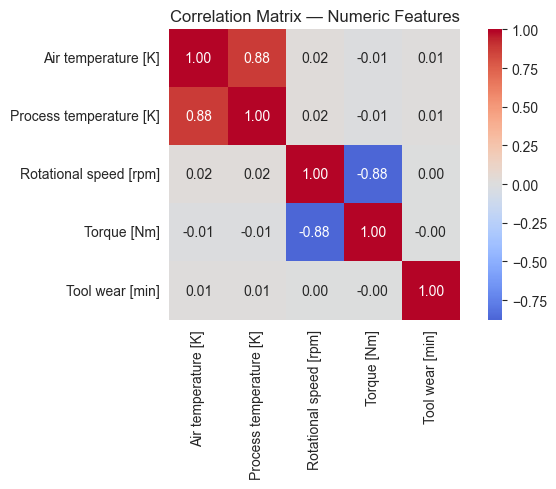

In [12]:
plt.figure(figsize=(7, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.show()

**Observation:** `Air temperature [K]` and `Process temperature [K]` are strongly
correlated (~0.88), which makes sense — process temperature is generated from air temperature
plus a small offset. `Torque [Nm]` and `Rotational speed [rpm]` show a clear negative
correlation (~-0.87), consistent with a constant-power milling process: as speed rises, torque
falls, and vice versa. `Tool wear [min]` is essentially uncorrelated with the other four features,
meaning it carries independent information rather than duplicating an existing signal.

### 6.2 Feature vs. Reason of Failure

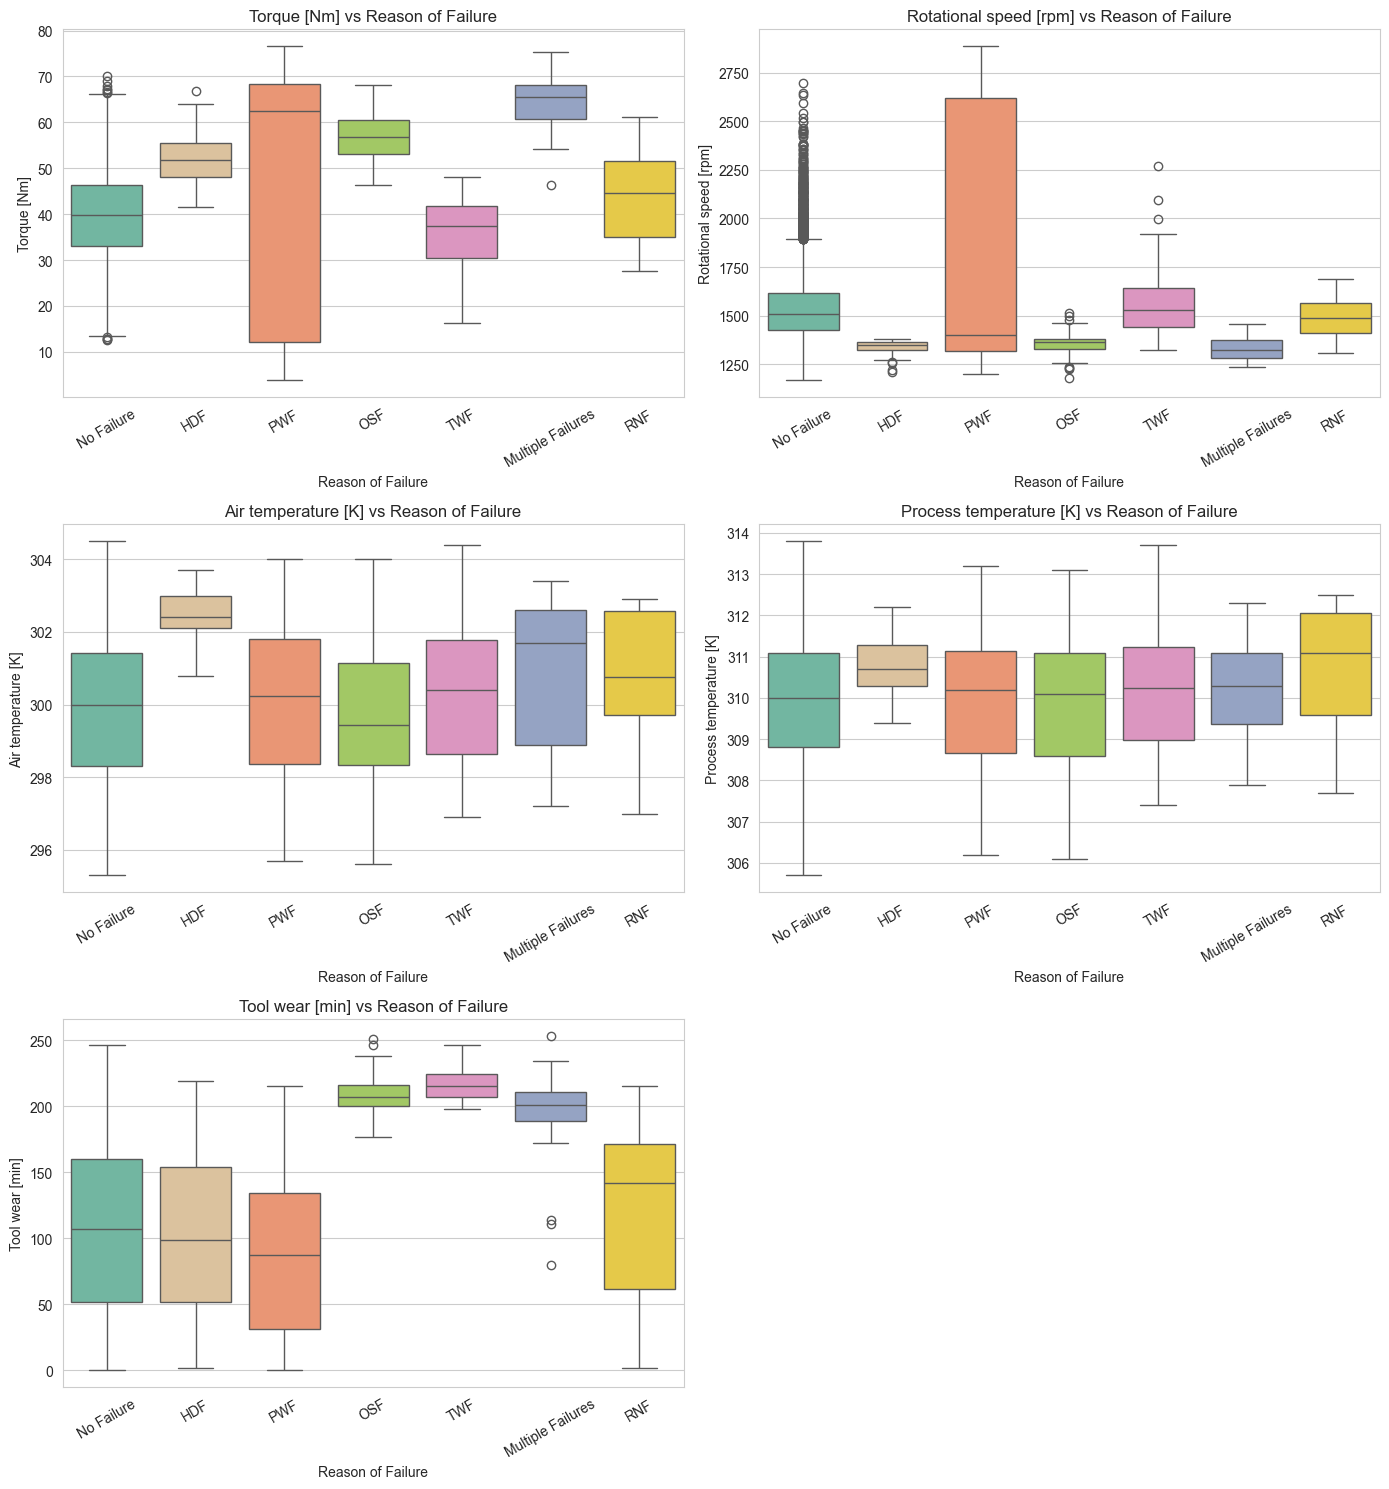

In [13]:
order = df["Reason of Failure"].value_counts().index

fig, axes = plt.subplots(3, 2, figsize=(14, 15))
axes = axes.flatten()

plot_cols = ["Torque [Nm]", "Rotational speed [rpm]", "Air temperature [K]",
             "Process temperature [K]", "Tool wear [min]"]

for i, col in enumerate(plot_cols):
    sns.boxplot(x="Reason of Failure", y=col, data=df, order=order, ax=axes[i], palette="Set2",
                hue="Reason of Failure", legend=False)
    axes[i].set_title(f"{col} vs Reason of Failure")
    axes[i].tick_params(axis="x", rotation=30)

axes[-1].axis("off")
plt.tight_layout()
plt.show()

**Which features look related to which failures:**

- **`Torque [Nm]` vs failure:** `Power Failure` rows cluster at unusually low **or** high torque
  (mechanical power outside the safe band), while `Overstrain Failure` rows sit at the high end —
  both consistent with the mechanical definitions of these failure modes.
- **`Rotational speed [rpm]` vs failure:** mirrors torque in the opposite direction — `Power
  Failure` again stands out, this time with unusually high or low speed, matching the
  constant-power relationship seen in the correlation matrix.
- **Temperature features vs failure:** `Heat Dissipation Failure` rows show a visibly smaller gap
  between process and air temperature than the rest of the data — heat isn't dissipating
  properly, which is precisely how HDF is defined.
- **`Tool wear [min]` vs failure:** `Tool Wear Failure` rows sit at the very top of the tool-wear
  range, and `Overstrain Failure` rows also skew high — overstrain in this dataset is a function
  of tool wear × torque, so this tracks.
- `No Failure` and `Random Failure` (`RNF`) both look like the "background" distribution across
  every feature — expected, since `RNF` is defined as failing with a small fixed probability
  regardless of any sensor reading.

## 7. Preprocessing Pipeline

From here on, the goal is a **leakage-free** pipeline. The order is fixed and deliberate:

```
Raw Data
  -> Separate Features (X) and Target (y)
  -> Train/Test Split FIRST (stratified, because the target is imbalanced)
  -> Feature Engineering (row-wise, applied identically to train & test)
  -> Categorical Encoding (fit on train only)
  -> Feature Scaling (fit on train only)
  -> SMOTE (training data only)
```

Everything that *learns* a parameter from the data (the scaler's mean/std, the encoder's
category list, SMOTE's synthetic neighbors) is fit **only** on the training set and then applied
to the test set — the test set never influences any of these parameters.

### 7.1 Separate Features and Target

Before splitting, a few columns must be dropped — not because they're uninteresting, but because
keeping them would leak the target's own definition into the model:

- `TWF`, `HDF`, `PWF`, `OSF`, `RNF` — these are literally the flags used to *build* the target in
  Section 2. Keeping any of them as a feature would let the model "cheat" by reading the answer.
- `Machine failure` — this is 1 whenever `Reason of Failure` is anything other than `No Failure`,
  so it's just the target restated as a binary flag. Same leakage problem.
- `UDI`, `Product ID` — row identifiers with no predictive meaning; `Product ID` also encodes the
  `Type` letter, which we already have as its own clean column.

In [14]:
LEAKAGE_COLUMNS = ["UDI", "Product ID", "Machine failure"] + FAILURE_FLAGS
TARGET = "Reason of Failure"

X = df.drop(columns=LEAKAGE_COLUMNS + [TARGET])
y = df[TARGET]

print("Feature columns:", X.columns.tolist())
X.head()

Feature columns: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


### 7.2 Train/Test Split FIRST (Stratified)

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain class distribution:\n", y_train.value_counts())
print("\nTest class distribution:\n", y_test.value_counts())

Train shape: (8000, 6)  Test shape: (2000, 6)

Train class distribution:
 Reason of Failure
No Failure           7722
HDF                    85
PWF                    64
OSF                    62
TWF                    34
Multiple Failures      19
RNF                    14
Name: count, dtype: int64

Test class distribution:
 Reason of Failure
No Failure           1930
HDF                    21
OSF                    16
PWF                    16
TWF                     8
Multiple Failures       5
RNF                     4
Name: count, dtype: int64


Stratifying keeps the same class proportions in both splits, and every class has enough
training examples (smallest class: 14) for SMOTE's default neighborhood size later — no special
workarounds needed here, because we're working with the real class counts instead of an
already-resampled file.

### 7.3 Feature Engineering

Two domain-based mechanical features, computed row-by-row (no fitting involved, so this is safe
to apply identically to train and test with no leakage):

- **Mechanical Power** — `Power = Torque × Angular velocity`, where angular velocity converts
  rotational speed from rpm to rad/s (`× 2π / 60`). Power is a direct driver of `Power Failure`:
  the failure is defined by power falling outside a safe band, so this feature encodes that
  mechanism explicitly rather than leaving the model to reconstruct it from torque and speed
  separately.
- **Temperature Difference** — `Process temperature − Air temperature`. `Heat Dissipation
  Failure` is defined by this gap being too small, so representing it as its own feature gives
  the model a direct, low-noise signal instead of relying on it to learn the subtraction from two
  correlated raw columns.

In [16]:
def engineer_features(X_input: pd.DataFrame) -> pd.DataFrame:
    '''Row-wise feature engineering — safe to apply to train and test independently.'''
    X_out = X_input.copy()
    X_out["Power [W]"] = X_out["Torque [Nm]"] * X_out["Rotational speed [rpm]"] * (2 * np.pi / 60)
    X_out["Temp Difference [K]"] = X_out["Process temperature [K]"] - X_out["Air temperature [K]"]
    return X_out

X_train_fe = engineer_features(X_train)
X_test_fe = engineer_features(X_test)

X_train_fe[["Torque [Nm]", "Rotational speed [rpm]", "Power [W]",
            "Air temperature [K]", "Process temperature [K]", "Temp Difference [K]"]].head()

,Torque [Nm],Rotational speed [rpm],Power [W],Air temperature [K],Process temperature [K],Temp Difference [K]
2023,54.2,1444,8195.870690,298.7,308.5,9.8
3819,36.4,1567,5973.089168,302.2,310.7,8.5
9006,41.8,1417,6202.613928,297.3,307.9,10.6
6343,23.0,1827,4400.428830,300.2,309.8,9.6
6488,54.4,1330,7576.683722,300.7,309.8,9.1


### 7.4 Encoding: One-Hot vs. Ordinal for `Type`

`Type` takes values `L`, `M`, `H` (product quality variant), but these are **nominal**, not
ordinal — there is no meaningful numeric order or fixed spacing between "Low", "Medium", and
"High" quality in how the dataset defines them; they're just three separate categories. Ordinal
Encoding would silently invent a distance between categories (e.g. treating `H − L = 2×(M − L)`),
which is not a real, backed relationship — a bad assumption to bake into the features. **One-Hot
Encoding** is the correct choice here: it treats the three categories as independent, unordered
groups, with no fabricated numeric relationship between them. With only 3 categories, the
dimensionality cost of one-hot is negligible.

### 7.5 Scaling & 7.6 Encoding — Fit on Training Data Only

In [17]:
numeric_features = ["Air temperature [K]", "Process temperature [K]",
                     "Rotational speed [rpm]", "Torque [Nm]", "Tool wear [min]",
                     "Power [W]", "Temp Difference [K]"]
categorical_features = ["Type"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])

### 7.7 SMOTE — Training Data Only, via an `imblearn` Pipeline

The scaler, the encoder, and SMOTE are chained into a single `imblearn` pipeline. Calling
`fit_resample` on this pipeline fits the scaler and encoder on `X_train` only, transforms
`X_train`, then oversamples the *transformed* training data with SMOTE. The test set is
transformed afterward using the already-fitted `preprocessor` — it is never resampled, and it
never contributes to fitting anything.

In [18]:
preprocessing_pipeline = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
])

# Fit + resample: training data only
X_train_processed, y_train_processed = preprocessing_pipeline.fit_resample(X_train_fe, y_train)

# Transform-only (no fitting, no resampling): test data
X_test_processed = preprocessing_pipeline.named_steps["preprocessor"].transform(X_test_fe)
y_test = y_test.reset_index(drop=True)

feature_names = preprocessing_pipeline.named_steps["preprocessor"].get_feature_names_out()

print("X_train_processed:", X_train_processed.shape)
print("X_test_processed: ", X_test_processed.shape)
print("\nFeature names:", list(feature_names))

X_train_processed: (54054, 9)
X_test_processed:  (2000, 9)

Feature names: ['num__Air temperature [K]', 'num__Process temperature [K]', 'num__Rotational speed [rpm]', 'num__Torque [Nm]', 'num__Tool wear [min]', 'num__Power [W]', 'num__Temp Difference [K]', 'cat__Type_L', 'cat__Type_M']


In [19]:
print("Training class distribution BEFORE SMOTE:")
print(y_train.value_counts())
print("\nTraining class distribution AFTER SMOTE:")
print(pd.Series(y_train_processed).value_counts())
print("\nTest class distribution (untouched, reflects real-world imbalance):")
print(y_test.value_counts())

Training class distribution BEFORE SMOTE:
Reason of Failure
No Failure           7722
HDF                    85
PWF                    64
OSF                    62
TWF                    34
Multiple Failures      19
RNF                    14
Name: count, dtype: int64

Training class distribution AFTER SMOTE:
Reason of Failure
No Failure           7722
HDF                  7722
Multiple Failures    7722
PWF                  7722
OSF                  7722
RNF                  7722
TWF                  7722
Name: count, dtype: int64

Test class distribution (untouched, reflects real-world imbalance):
Reason of Failure
No Failure           1930
HDF                    21
OSF                    16
PWF                    16
TWF                     8
Multiple Failures       5
RNF                     4
Name: count, dtype: int64


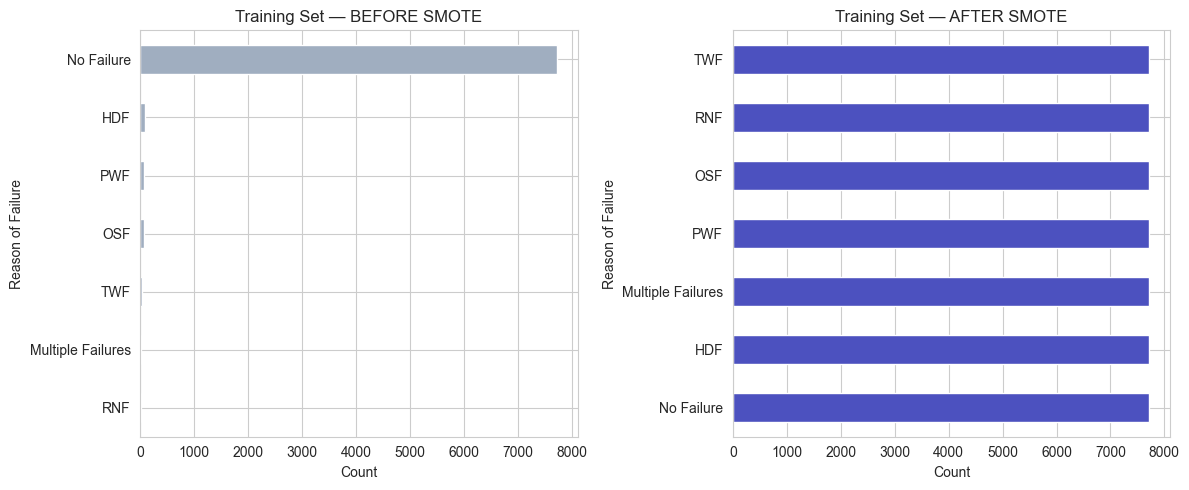

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

y_train.value_counts().sort_values().plot(kind="barh", ax=axes[0], color="#a0aec0")
axes[0].set_title("Training Set — BEFORE SMOTE")
axes[0].set_xlabel("Count")

pd.Series(y_train_processed).value_counts().sort_values().plot(
    kind="barh", ax=axes[1], color="#4c51bf")
axes[1].set_title("Training Set — AFTER SMOTE")
axes[1].set_xlabel("Count")

plt.tight_layout()
plt.show()

**Result:** every class in the training set is now balanced to the majority class count.
The test set (`X_test_processed`, `y_test`) is left with its original, real-world imbalance —
exactly what a deployed model would actually see, so evaluation metrics computed on it stay
meaningful.

## 8. Final Model-Ready Outputs

In [21]:
X_train_processed_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_processed_df = pd.DataFrame(X_test_processed, columns=feature_names)
y_train_processed = pd.Series(y_train_processed, name="Reason of Failure")

print("X_train_processed:", X_train_processed_df.shape)
print("y_train_processed:", y_train_processed.shape)
print("X_test_processed: ", X_test_processed_df.shape)
print("y_test:            ", y_test.shape)

X_train_processed_df.head()

X_train_processed: (54054, 9)
y_train_processed: (54054,)
X_test_processed:  (2000, 9)
y_test:             (2000,)


,num__Air temperature [K],num__Process temperature [K],num__Rotational speed [rpm],num__Torque [Nm],num__Tool wear [min],num__Power [W],num__Temp Difference [K],cat__Type_L,cat__Type_M
0,-0.652499,-1.015001,-0.521767,1.420045,-0.719316,1.794037,-0.199942,1.0,0.0
1,1.099697,0.471029,0.169978,-0.370404,-0.121186,-0.296619,-1.504133,1.0,0.0
2,-1.353378,-1.420282,-0.673614,0.172766,1.232476,-0.080737,0.602636,1.0,0.0
3,0.098442,-0.136892,1.632204,-1.718271,-1.600770,-1.775798,-0.400587,1.0,0.0
4,0.348756,-0.136892,-1.162897,1.440163,0.996372,1.211656,-0.902199,1.0,0.0


### Save to Disk

In [22]:
X_train_processed_df.to_csv("X_train_processed.csv", index=False)
y_train_processed.to_csv("y_train_processed.csv", index=False)
X_test_processed_df.to_csv("X_test_processed.csv", index=False)
y_test.to_csv("y_test.csv", index=False)

print("Saved: X_train_processed.csv, y_train_processed.csv, X_test_processed.csv, y_test.csv")

Saved: X_train_processed.csv, y_train_processed.csv, X_test_processed.csv, y_test.csv


## 9. Summary

- Started from the **raw, untouched** AI4I 2020 release (`ai4i2020.csv`) — no pre-scaling, no
  pre-balancing.
- Derived the 7-class `Reason of Failure` target explicitly from the five raw failure flags, with
  the mapping documented in Section 2.
- Ran EDA, univariate, and bivariate analysis on the raw data to understand distributions and
  which features relate to which failure modes.
- Split **before** any fitting step, added two domain features, one-hot encoded `Type`, scaled
  numeric features, and applied SMOTE — with every fitted step (encoder, scaler, SMOTE) touching
  training data only.
- Output: `X_train_processed`, `y_train_processed`, `X_test_processed`, `y_test` — balanced
  training data, untouched test data, ready for model training in a follow-up notebook.